In [23]:
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [24]:
def set_seed(seed=67):
    # Set `PYTHONHASHSEED` environment variable at a fixed value
    import os
    os.environ['PYTHONHASHSEED'] = str(seed)

    # Python built-in random seed
    random.seed(seed)

    # NumPy random seed
    np.random.seed(seed)

    # PyTorch random seed for CPU
    torch.manual_seed(seed)

    # PyTorch random seed for all GPUs (if available)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(67)

In [25]:
batch_size = 64

In [26]:
train_dataset = datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transforms.ToTensor()
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [27]:
# test_dataset = datasets.MNIST(
#     root='./data', 
#     train=False, 
#     download=True, 
#     transform=transforms.ToTensor()
# )
# test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [28]:
c=1
for x,y in train_loader:
    print(f"x: {x}, y: {y}")
    print(f"len x: {len(x)}, len y: {len(y)}")
    if c==1:
        break
    c+=1
del c

x: tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ...,

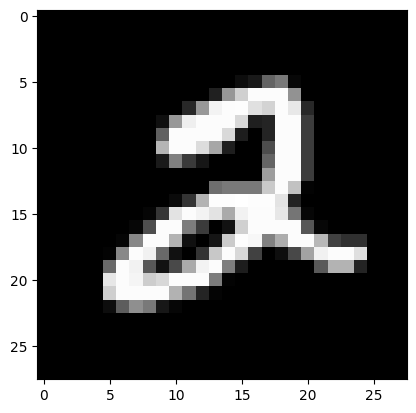

In [29]:
mnist_2d = train_dataset[5][0].reshape(28,28)
plt.imshow(mnist_2d, cmap='gray')
del mnist_2d
# print(mnist_2d)
# train_dataset[1][0]

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [31]:
# The model is simple to save space in the ESP32-S3
class MNISTEsp32Net(nn.Module):
    def __init__(self):
        super(MNISTEsp32Net, self).__init__()
        # Using relu since it maps negative values cleanly to 0.
        self.network = nn.Sequential(
            nn.Linear(784, 100),
            nn.ReLU(),
            nn.Linear(100, 40),
            nn.ReLU(),
            nn.Linear(40, 10)
        )
        
    def forward(self, x):
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MNISTEsp32Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Training model...")
model.train()
for epoch in range(30):
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.view(batch_X.size(0), -1)
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Training model...
Epoch 1, Loss: 0.3875
Epoch 2, Loss: 0.1692
Epoch 3, Loss: 0.1232
Epoch 4, Loss: 0.0956
Epoch 5, Loss: 0.0771
Epoch 6, Loss: 0.0625
Epoch 7, Loss: 0.0522
Epoch 8, Loss: 0.0450
Epoch 9, Loss: 0.0384
Epoch 10, Loss: 0.0337
Epoch 11, Loss: 0.0292
Epoch 12, Loss: 0.0246
Epoch 13, Loss: 0.0208
Epoch 14, Loss: 0.0180
Epoch 15, Loss: 0.0174
Epoch 16, Loss: 0.0149
Epoch 17, Loss: 0.0133
Epoch 18, Loss: 0.0125
Epoch 19, Loss: 0.0111
Epoch 20, Loss: 0.0123
Epoch 21, Loss: 0.0101
Epoch 22, Loss: 0.0086
Epoch 23, Loss: 0.0080
Epoch 24, Loss: 0.0108
Epoch 25, Loss: 0.0075
Epoch 26, Loss: 0.0076
Epoch 27, Loss: 0.0053
Epoch 28, Loss: 0.0080
Epoch 29, Loss: 0.0086
Epoch 30, Loss: 0.0072


In [32]:
# Symmetrically quantize tensor to int8
def quantize_to_int8(tensor):
    float_weights = tensor.detach().cpu().numpy()
    
    # Take maximum absolute value as scale factor
    max_val = np.max(np.abs(float_weights))
    
    # Prevent division by zero if weights are empty or zero
    if max_val == 0:
        return float_weights.astype(np.int8), 1.0
        
    # Calculate scale factor: maps max_val to 127
    scale = 127.0 / max_val
    
    # Quantize, round, and clip to valid int8 boundaries
    quantized_weights = np.round(float_weights * scale)
    quantized_weights = np.clip(quantized_weights, -128, 127).astype(np.int8)
    
    # The scale stored here is used during inference to dequantize (or rescale) layer outputs
    return quantized_weights, scale

# Extract and quantize
model.eval()
state_dict = model.state_dict()

quantized_model = {}
for key in state_dict.keys():
    if 'weight' in key or 'bias' in key:
        q_weights, scale = quantize_to_int8(state_dict[key])
        quantized_model[key] = {
            "int8_data": q_weights,
            "scale": scale
        }
        print(f"Layer: {key} | Shape: {q_weights.shape} | Quantization Scale: {scale:.4f}")

# first layer's quantized int8 weights
first_layer_weights = quantized_model['network.0.weight']['int8_data']

Layer: network.0.weight | Shape: (100, 784) | Quantization Scale: 94.3409
Layer: network.0.bias | Shape: (100,) | Quantization Scale: 418.6591
Layer: network.2.weight | Shape: (40, 100) | Quantization Scale: 109.8645
Layer: network.2.bias | Shape: (40,) | Quantization Scale: 306.6013
Layer: network.4.weight | Shape: (10, 40) | Quantization Scale: 114.3184
Layer: network.4.bias | Shape: (10,) | Quantization Scale: 629.9784


In [33]:
def export_to_c_header(quantized_model, filename="model_weights.h"):
    with open(filename, "w") as f:
        f.write("#pragma once\n#include <stdint.h>\n\n")
        
        for key, data in quantized_model.items():
            q_weights = data["int8_data"] # quantized weights
            scale = data["scale"]
            
            # since dots are invalid in a variable name
            clean_name = key.replace('.', '_')
            
            # Flatten the N-dimensional numpy array to a 1D C array
            flat_weights = q_weights.flatten()
            array_str = ", ".join(map(str, flat_weights))
            
            f.write(f"// Original Shape: {q_weights.shape}\n")
            f.write(f"const float {clean_name}_scale = {scale}f;\n")
            f.write(f"const int8_t {clean_name}[{len(flat_weights)}] = {{{array_str}}};\n\n")

export_to_c_header(quantized_model)